# This notebook is for computing the Eros metric for events where the BES diagnostic was near the pedestal top. H mode is not included in the analysis

In [2]:
import os #allow for multithreading in numpy
%env OMP_NUM_THREADS = 32
%env OPENBLAS_NUM_THREADS = 32
%env MKL_NUM_THREADS = 32
%env VECLIB_MAXIMUM_THREADS = 32
%env NUMEXPR_NUM_THREADS = 32
import numpy as np
import scipy
import matplotlib.patches as mpatches
import matplotlib.ticker as tkr
import matplotlib.pyplot as plt
import custom_functions.data_processing_functions as dpf
import custom_functions.cluster_analysis_functions as cluster_func
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import h5py
import pandas as pd

env: OMP_NUM_THREADS=32
env: OPENBLAS_NUM_THREADS=32
env: MKL_NUM_THREADS=32
env: VECLIB_MAXIMUM_THREADS=32
env: NUMEXPR_NUM_THREADS=32


In [3]:
plt.rcParams.update({'font.size': 20})


In [4]:
magnetics_path = 'computed_matrices/elm_free_matrices/filtered_magnetics_dict_elm_free.npy'
magnetics_dict = np.load(magnetics_path, allow_pickle = True).item()

In [5]:
Eros_dissimilarity_matrix = np.load('custom_functions/elm_free_supplement_functions/Eros_R_edge_dissimilarity_matrix_magnetics.npy')
bes_path = 'computed_matrices/elm_free_matrices/elm_free_bes_dict_filtered_new_start.npy'
bes_dict = np.load(bes_path, allow_pickle=True).item()
magnetics_path = 'computed_matrices/elm_free_matrices/filtered_magnetics_dict_elm_free.npy'
magnetics_dict = np.load(magnetics_path, allow_pickle=True).item()
Eros_dict = np.load('computed_matrices/elm_free_matrices/elm_free_magnetics_eros_dict.npy', allow_pickle=True).item()
pedestal_dict  = np.load('elm_free_bes_data/all_pedestal_dict_elm_free.npy', allow_pickle=True).item()
acceptable_ids_dict1 = np.load('elm_free_bes_data/bes_sensors_in_pedestal_top.npy', allow_pickle=True).item()
acceptable_ids_dict2 = np.load('elm_free_bes_data/bes_sensors_in_pedestal_foot.npy', allow_pickle=True).item()
#parameter dict with shaping, and q95 for the elm free dict
elm_free_param_dict = np.load('ELM_free_data_analysis/elm_free_param_dict.npy', allow_pickle=True).item()




In [6]:
print(magnetics_dict['00001'].keys())

dict_keys(['mpi.11m067d', 'mpi.66m020d', 'mpi.66m067d', 'time', 'mpi.66m097d', 'mpi.66m127d', 'mpi.66m132d', 'mpi.66m137d', 'mpi.66m157d', 'mpi.66m200d', 'mpi.66m247d', 'mpi.66m277d', 'mpi.66m307d', 'mpi.66m312d', 'mpi.66m322d', 'mpi.66m340d'])


In [7]:
event_ids = np.load('computed_matrices/elm_free_matrices/ids_in_edge.npy', allow_pickle=True)
print(len(event_ids))


735


In [8]:
print(np.shape(Eros_dissimilarity_matrix))


(735, 735)


In [9]:
print(np.argmax(Eros_dissimilarity_matrix)) #need to mod this by the length of pairs since the matrix is symmetric


72437


# Eros dissimilarity matrix 

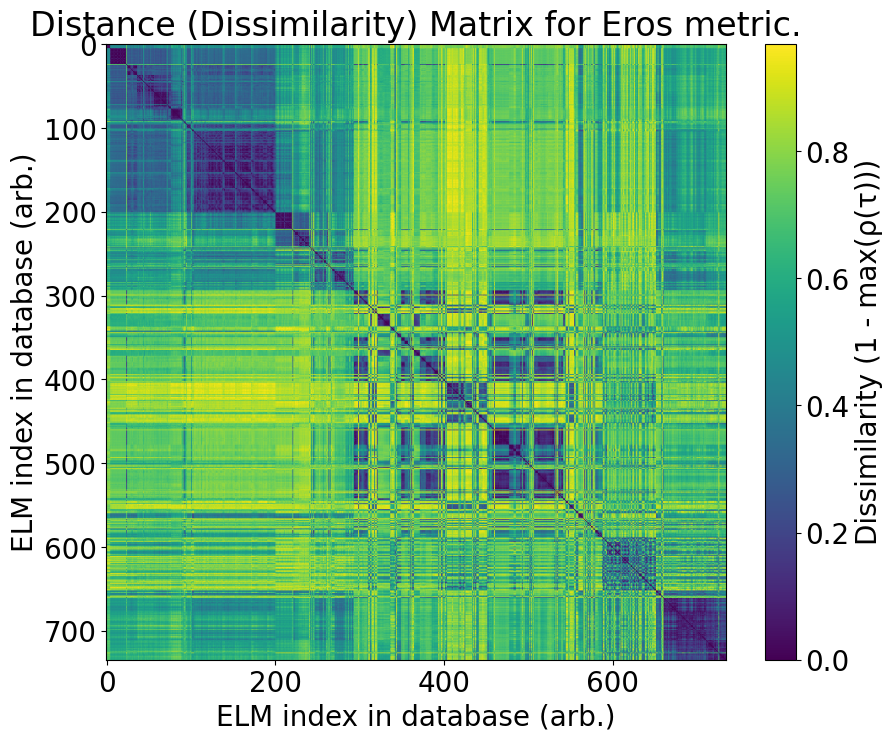

In [10]:
plt.figure(figsize=(10, 8))
plt.imshow(Eros_dissimilarity_matrix, cmap='viridis', aspect='auto')
plt.colorbar(label='Dissimilarity (1 - max(ρ(τ)))')
# plt.clim(0, )  # Adjust the values to increase contrast
plt.title('Distance (Dissimilarity) Matrix for Eros metric.') 
plt.xlabel('ELM index in database (arb.)')
plt.ylabel('ELM index in database (arb.)')
plt.savefig('Distance (Dissimilarity) Matrix for Eros metric.')
plt.show()

In [11]:
linked_Eros = linkage(squareform(Eros_dissimilarity_matrix), method = 'ward') #need to transform from a distance matrix to a feature vector

In [12]:
print(np.shape(linked_Eros))


(734, 4)


[ 2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


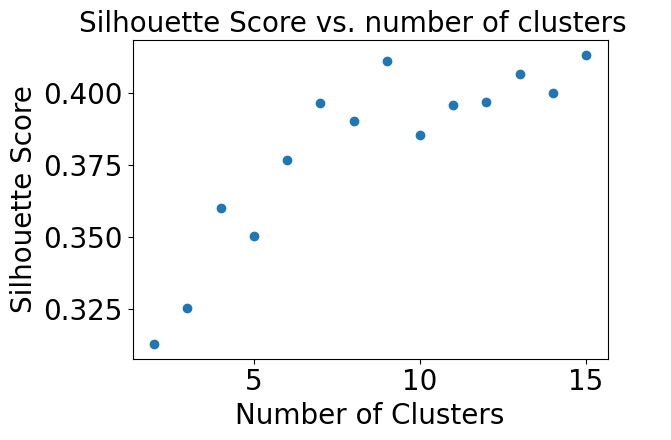

In [13]:
sil_score_arr = cluster_func.silhouette_comparison(Eros_dissimilarity_matrix)

sil_clusters = np.linspace(2,len(sil_score_arr)+1, len(sil_score_arr))
print(sil_clusters)
plt.figure(figsize = (6.4,4.8))
plt.title('Silhouette Score vs. number of clusters    ', size = 20)
plt.xlabel('Number of Clusters', size = 20)
plt.ylabel('Silhouette Score', size = 20)
plt.scatter(sil_clusters, sil_score_arr)
plt.tight_layout()
plt.savefig('Paper_figures/magnetics_silhouette_score_edge.pdf', dpi = 600, transparent = True)
plt.show()

# Based on the elbow in the above graph, we can pick a threshold in the dendrogram to achieve the "optimal" number of clusters

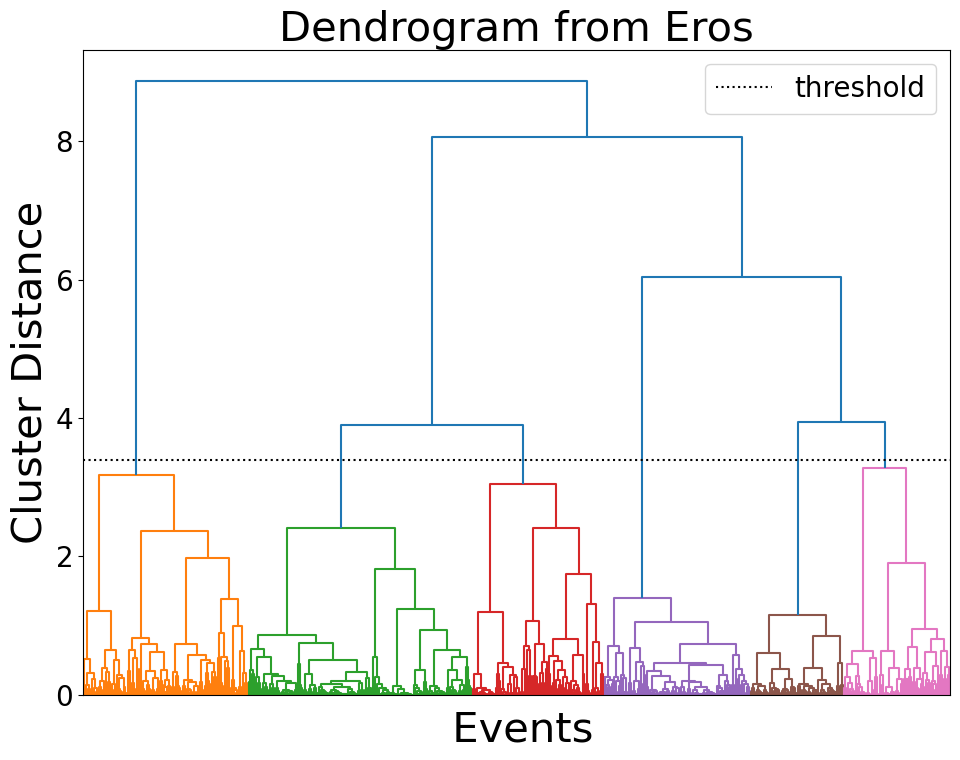

In [14]:
threshold = 3.4
plt.figure(figsize = (10,8))
dendrogram(linked_Eros,
    orientation='top',
    labels=event_ids,
    leaf_rotation=90,
    color_threshold= threshold
)
plt.axhline(threshold, c = 'k', linestyle = ':', label = 'threshold')
plt.gca().set_xticklabels([])
plt.yticks(fontsize = 20)
plt.xlabel(' Events', fontsize = 30)
plt.ylabel('Cluster Distance', fontsize = 30)
plt.title('Dendrogram from Eros', fontsize = 30)
plt.tight_layout()
plt.savefig('Paper_figures/magnetics_dendrogram_edge.pdf', dpi = 600, transparent = True)
plt.legend(fontsize = 20)

In [15]:
num_clusters_new = 6 #these are just selected based off of the number of colors in the dendrogram for each linkage matrix


labels_new = fcluster(linked_Eros, t = num_clusters_new, criterion = 'maxclust')



In [16]:
keys_new = [str(i) for i in range(1, num_clusters_new+1)]


In [17]:
cluster_save_path = f'magnetics_top_clusters_{num_clusters_new}.npy'
cluster_dict_new = {}
for key in keys_new:
    cluster_dict_new[key] = []


In [18]:
for index, label in enumerate(labels_new):
    elm_index = event_ids[index]
    cluster_dict_new[str(label)].append(elm_index) #assign event ids to the clusters in the dictionary for the old Eros method
np.save(cluster_save_path, cluster_dict_new, allow_pickle=True)
print('cluster dict saved')

cluster dict saved


# How well does hierarchical clustering seperate between the different kinds of regimes that are present in the data?

# This run does not include H mode so we comment this out

In [19]:
L_count = 0
QH_count = 0
WPQH_count = 0
for id in event_ids:
    label = bes_dict[id]['label']
    if label == 0:
        L_count+=1
    if label == 2:
        QH_count+=1
    if label == 3:
        WPQH_count+=1

print(f'L count: {L_count}')
print(f'QH count: {QH_count}')
print(f'WPQH count: {WPQH_count}')

L count: 294
QH count: 294
WPQH count: 147


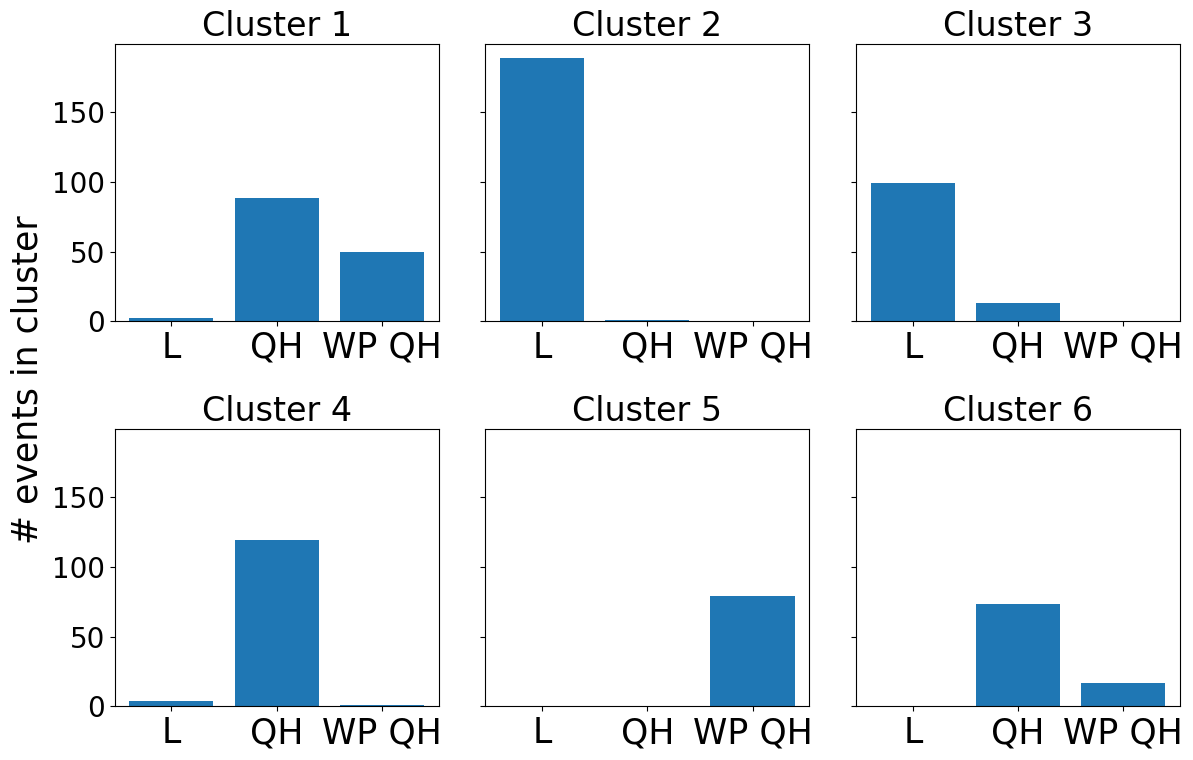

In [20]:
regimes = ['L', 'QH', 'WP QH']
fig,axs = plt.subplots(2,3, figsize = (12,8), sharey=True)
axs = axs.flatten()
for i,cluster in enumerate(cluster_dict_new.keys()): #cycle over all clusters
    #count the number of items in the cluster that correspond to each regime
    L_mode_counter = 0
    #H_mode_counter = 0
    QH_counter = 0
    WP_counter = 0

    for id in cluster_dict_new[cluster]: #cycle over all ids  in the cluster
        label = bes_dict[id]['label']
        if label == 0:
            L_mode_counter +=1
        #if label == 1:
            #H_mode_counter+=1
        if label == 2:
            QH_counter+=1
        if label == 3:
            WP_counter+=1
    #plot in a bar chart

    axs[i].set_title(f'Cluster {cluster}')
    axs[i].bar(regimes, [L_mode_counter, QH_counter, WP_counter])
    axs[i].tick_params(axis="x", labelsize=25)
if num_clusters_new%2 == 1:
    axs[-1].remove() 
fig.text(-.01, 0.5, '# events in cluster', va='center', rotation='vertical', fontsize = 25)
fig.tight_layout()
# plt.subplots_adjust(wspace = 0, hspace = .35)
fig.savefig(f'Paper_figures/ELM_free_regimes_{num_clusters_new}_clusters_magnetics_edge.pdf', dpi = 600, transparent=True, bbox_inches = 'tight')

In [21]:
for id in cluster_dict_new['4']:
    good_sensors = []
    if bes_dict[id]['label'] == 0:
        print(
              f'shot: {bes_dict[id]['shot']}. from t start:',
              f'{bes_dict[id]['time'][0]} to {bes_dict[id]['time'][-1]} id: {id}. ped top at {pedestal_dict[id]['pe']['top']}')

shot: 159372. from t start: 921.0 to 1366.998 id: 00105. ped top at 0.7755906165235353
shot: 169379. from t start: 1000.88 to 1134.998 id: 01246. ped top at 0.8738057919153756
shot: 179634. from t start: 800.0 to 4999.998 id: 02608. ped top at 0.7707459615856245
shot: 189602. from t start: 1904.852 to 1927.998 id: 03242. ped top at 0.8242638492527719


shot: 161608 has good sensors at [26, 27, 28, 29, 30]. from t start: 863.156 to 880.054 id: 00834. ped top at 0.746880840052035
id : 00834 has a sensor at [0.86631011 0.0012125 ]

# All below this cell is from the elm free data. Let's neglect the comparrison of plasma paramters for a second and just see if these clusters can reasonably identify the difference between the different kinds of discharges

# I would like to reproduce the plots in the 2016 ELM classification paper that indicate if the clusters found by the algorithm actually meaningfully represent different clusters or not. I'm going to try to pull in some plasma parameters and get the average values of that parameter over the different events in each cluster

 # The parameters of interest (from the 2016 paper) are:
- Plasma Current
- Toroidal B fieid
- Neutral beam power
- magnetic balence d_{r}^{sep}
- safety factor q_{95}
- Stored energy W_{dia}
- Stored energy loss W_{loss}
- Elongation \kappa
- Lower triangularity \delta_l
- Pedestal ele. den. height, ne  ped (10 /cm  13 3)
- Pedestal ele. den. width, ∆Rne  ped
- Pedestal ele. temp. height, Te  ped (keV)
- Pedestal ele. temp. width, ∆RTe  ped (cm)
- Zeff
- Collisionality, νei (10^6)
- Total beta, β = 2μ (2p )/B  e  0  ped 2
- Poloidal beta, β = 2μ (2p )/B  p ep  0  ped 2
- Alfvén time, τ = R /v  A 0 A (μs)

# We don't seem to have a lot of these! I'll start by loading in:
- Toroidal B
- Plasma current
- ECH power
- neutral beam power

# Distribution of freqeuncies in each cluster (PSD). Need to do a comparison between the channels that actually got compared for each pair of ids

In [22]:
def in_cluster_comparison(data_dict, cluster_dict, bes_dict, cluster_num, dt = 1):
    #can use dt to correct any scaling errors if need be
    data_cluster_dict = {'L': [], 'QH': [], 'WPQH': []}
    num_missing = 0
    total_keys = len(list(data_dict.keys()))
    for id in cluster_dict[str(cluster_num)]:
        try:
            data_dict[id]['signals']
        except:
            num_missing+=1
            continue
        if bes_dict[id]['label'] == 0:
            data_cluster_dict['L'].append(data_dict[id]['signals']*dt)

        if bes_dict[id]['label'] == 2:
            data_cluster_dict['QH'].append(data_dict[id]['signals']*dt)

        if bes_dict[id]['label'] == 3:
            data_cluster_dict['WPQH'].append(data_dict[id]['signals']*dt)
    print(f'missing {num_missing} of {total_keys} keys')
    return data_cluster_dict

In [23]:
def pastel_boxplot(data_dict, clusters_given, y_axis, title = None, return_fig = False):
    '''
    Function for making pastel blue boxplots for parameter dict

    data_dict: dict where each key is a cluster label ('1', '2', etc.), and each value is a list containing the values of a parameter
    in that cluster
    clusters_given: list of strings. Clusters to include in boxplot
    y_axis: str. y axis label for the plot
    title: default None. Else, a string used for the title of the plot
    return_fig: default False. Can be used to return the figure for saving later
    '''
    data = [data_dict[cluster] for cluster in QH_mode_torque_dict if cluster in clusters_given]

    labels = [f"Cluster {c}" for c in clusters_given]

    fig, ax1 = plt.subplots(figsize=(8, 6))

    bp1 = ax1.boxplot(data, widths=0.3, 
                    patch_artist=True, **boxplot_style)
    ax1.set_xlabel('', fontsize=20)
    ax1.set_ylabel(y_axis, fontsize=20)
    ax1.tick_params(axis='y')


    ax1.set_xticks(np.arange(1, len(labels) + 1))
    ax1.set_xticklabels(labels)
    if title:
        plt.title(title, fontsize=25)


    for patch in bp1['boxes']:
        patch.set_facecolor('lightblue')

    plt.tight_layout()  
    if return_fig:
        
        return plt.gcf()
    
    


    

In [24]:
boxplot_style = {
    'whiskerprops': {'linewidth': 1.5},
    'medianprops': {'linewidth': 2},
    'capprops': {'linewidth': 1.5},
    'boxprops': {'linewidth': 1.5}
}

In [25]:
def numfmt_mega(x, pos):
    s = f'{x/10**6}'
    return s

yfmt_mega = tkr.FuncFormatter(numfmt_mega)

def numfmt_kila(x, pos):
    s = f'{x/10**3}'
    return s

yfmt_kila = tkr.FuncFormatter(numfmt_kila)


In [26]:
def most_active_channel(ts):
    return np.argmax(np.std(ts, axis = 1)) #return the channel with the largest std
        

In [27]:
label_dict = {0: 'L', 1: 'H', 2: 'QH', 3: 'WPQH'}

# What is the spatial distribution of the BES diagnostic for the different clusters?

# Parameters for cross-cluster comparison

In [28]:
def most_active_channel(ts):
    return np.argmax(np.std(ts, axis = 1)) #return the channel with the largest std
        

# What is the spatial distribution of the BES diagnostic for the different clusters?

# Parameters for cross-cluster comparison

In [29]:
elm_free_param_path = 'ELM_free_data_analysis/elm_free_param_dict.npy' 
param_dict = np.load(elm_free_param_path, allow_pickle=True).item()

In [30]:
print(param_dict['00001'].keys())

dict_keys(['q95', 'TRITOP', 'TRIBOT', 'KAPPA', 'ECHPWRC', 'PINJ', 'PRMTAN_PEPED'])


In [31]:
pedestal_height_dict = np.load('elm_free_bes_data/pedestal_heights.npy', allow_pickle = True).item()

pe_width_dict = {id: pedestal_dict[id]['pe']['foot'] - pedestal_dict[id]['pe']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}
ne_width_dict = {id: pedestal_dict[id]['ne']['foot'] - pedestal_dict[id]['ne']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}
te_width_dict = {id: pedestal_dict[id]['te']['foot'] - pedestal_dict[id]['te']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}


pe_height_dict = {id: pedestal_height_dict[id]['pe']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['pe'] != 0}
ne_height_dict = {id: pedestal_height_dict[id]['ne']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['ne'] != 0}
te_height_dict = {id: pedestal_height_dict[id]['te']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['te'] != 0}

pe_gradient_dict = {id: pedestal_height_dict[id]['pe']/pe_width_dict[id] for id in pedestal_height_dict.keys() if id in pe_width_dict.keys() and pe_width_dict[id] != 0.0}
te_gradient_dict = {id: pedestal_height_dict[id]['te']/te_width_dict[id] for id in pedestal_height_dict.keys() if id in pe_width_dict.keys() and te_width_dict[id] != 0.0}
ne_gradient_dict = {id: pedestal_height_dict[id]['ne']/ne_width_dict[id] for id in pedestal_height_dict.keys() if id in pe_width_dict.keys() and ne_width_dict[id] != 0.0}


In [32]:
nu_star_dict = np.load('elm_free_bes_data/nu_star_dict_elm_free.npy', allow_pickle=True).item()
nu_star_cluster_dict = cluster_func.cluster_comparison(nu_star_dict, cluster_dict_new)
q95_dict = {id: param_dict[id]['q95'] for id in param_dict.keys()}
tritop_dict = {id: param_dict[id]['TRITOP'] for id in param_dict.keys()}
tribot_dict = {id: param_dict[id]['TRIBOT'] for id in param_dict.keys()}
kappa_dict = {id: param_dict[id]['KAPPA'] for id in param_dict.keys()}
bt_ip = np.load('elm_free_bes_data/elm_free_bt_dict.npy', allow_pickle=True).item()
bt_dict = {id: bt_ip[id]['bt'] for id in bt_ip.keys()}
ip_dict = {id: bt_ip[id]['ip'] for id in bt_ip.keys()}
drsep_dict = np.load('elm_free_bes_data/drsep_dict_elm_free.npy', allow_pickle=True).item()
betan_dict = np.load('elm_free_bes_data/beta_dict_elm_free.npy', allow_pickle = True).item()

NBI_dict = np.load('elm_free_bes_data/NBI_elm_free_dict.npy', allow_pickle=True).item()
ECH_dict = np.load('elm_free_bes_data/ECH_elm_free_dict.npy', allow_pickle=True).item()
torque_dict = np.load('elm_free_bes_data/NBI_torque_elm_free_dict.npy', allow_pickle=True).item()
h98_dict = np.load('elm_free_bes_data/H98_dict_elm_free.npy', allow_pickle = True).item()

S_sum_S_dict = {}

for id in list(Eros_dict.keys())[:-1]:
    S_sum_S_dict[id] = Eros_dict[id]['S'][0] / np.sum(Eros_dict[id]['S'])

ip_mag_dict = {id: np.abs(ip_dict[id]) for id in ip_dict.keys()}
bt_mag_dict = {id: np.abs(bt_dict[id]) for id in bt_dict.keys()}

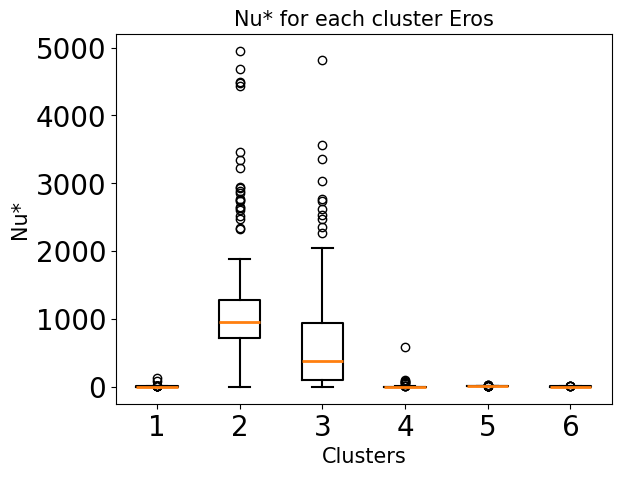

In [33]:
plt.figure()
plt.title('Nu* for each cluster Eros', fontsize = 15)
plt.ylabel('Nu*', fontsize = 15)
plt.xlabel('Clusters', fontsize = 15)
plt.boxplot(nu_star_cluster_dict.values(), **boxplot_style)
plt.show()

In [34]:
def regime_comparison(data_dict, bes_dict, cluster_dict, regime, num_missing = False):
    '''
    This script is for comparing different distributions of parameters across the different regimes from cluster to cluster
    data_dict: dict. Contains as keys the ids, and as values the parameter
    bes_dict: dict containing labels for each regime corresponding to the ids in each part of the database
    cluster_dict: each key is a cluster and the values are the ids in that cluster
    regime: string that will correspond to L, H, QH, WPQH
    '''
    cross_cluster_regime_dict = {}
    regime_dict = {'L': 0, 'H': 1,'QH': 2, 'WPQH': 3}
    missing = []
    for cluster in cluster_dict:
        cross_cluster_regime_dict[cluster] = []
        for id in cluster_dict[cluster]:
            label = bes_dict[id]['label']
            if label != regime_dict[regime]:
                continue
            if bool(data_dict[id]) == False:
                missing.append(id)
                continue
            if isinstance(data_dict[id], dict):
                cross_cluster_regime_dict[cluster].append(data_dict[id]['signals'])
            else:
                if isinstance(data_dict[id],str):
                    continue
                else:
                    cross_cluster_regime_dict[cluster].append(data_dict[id])
        
    if num_missing:
        return cross_cluster_regime_dict, missing
    else:
        return cross_cluster_regime_dict

# Just a cell where I make regime dicts for each of the different parameters

In [35]:

L_mode_NBI_dict = regime_comparison(NBI_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_NBI_dict, num_missing_QH_NBI = regime_comparison(NBI_dict, bes_dict, cluster_dict_new, 'QH', num_missing=True)
WPQH_mode_NBI_dict = regime_comparison(NBI_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ECH_dict = regime_comparison(ECH_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ECH_dict, num_missing_QH_ECH = regime_comparison(ECH_dict, bes_dict, cluster_dict_new, 'QH', num_missing=True)
WPQH_mode_ECH_dict = regime_comparison(ECH_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_torque_dict = regime_comparison(torque_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_torque_dict, num_missing_QH_torque = regime_comparison(torque_dict, bes_dict, cluster_dict_new, 'QH', num_missing=True)
WPQH_mode_torque_dict = regime_comparison(torque_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_q95_dict = regime_comparison(q95_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_q95_dict = regime_comparison(q95_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_q95_dict = regime_comparison(q95_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_tritop_dict = regime_comparison(tritop_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_tritop_dict = regime_comparison(tritop_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_tritop_dict = regime_comparison(tritop_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_tribot_dict = regime_comparison(tribot_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_tribot_dict = regime_comparison(tribot_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_tribot_dict = regime_comparison(tribot_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_te_dict = regime_comparison(te_height_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_te_dict = regime_comparison(te_height_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_te_dict = regime_comparison(te_height_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ne_dict = regime_comparison(ne_height_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ne_dict = regime_comparison(ne_height_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_ne_dict = regime_comparison(ne_height_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_pe_dict = regime_comparison(pe_height_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_pe_dict = regime_comparison(pe_height_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_pe_dict = regime_comparison(pe_height_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_te_width_dict = regime_comparison(te_width_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_te_width_dict = regime_comparison(te_width_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_te_width_dict = regime_comparison(te_width_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ne_width_dict = regime_comparison(ne_width_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ne_width_dict = regime_comparison(ne_width_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_ne_width_dict = regime_comparison(ne_width_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_pe_width_dict = regime_comparison(pe_width_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_pe_width_dict = regime_comparison(pe_width_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_pe_width_dict = regime_comparison(pe_width_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_te_gradient_dict = regime_comparison(te_gradient_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_te_gradient_dict = regime_comparison(te_gradient_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_te_gradient_dict = regime_comparison(te_gradient_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ne_gradient_dict = regime_comparison(ne_gradient_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ne_gradient_dict = regime_comparison(ne_gradient_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_ne_gradient_dict = regime_comparison(ne_gradient_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_pe_gradient_dict = regime_comparison(pe_gradient_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_pe_gradient_dict = regime_comparison(pe_gradient_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_pe_gradient_dict = regime_comparison(pe_gradient_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_kappa_dict = regime_comparison(kappa_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_kappa_dict = regime_comparison(kappa_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_kappa_dict = regime_comparison(kappa_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_h98_dict = regime_comparison(h98_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_h98_dict = regime_comparison(h98_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_h98_dict = regime_comparison(h98_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_bt_dict = regime_comparison(bt_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_bt_dict = regime_comparison(bt_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_bt_dict = regime_comparison(bt_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_ip_dict = regime_comparison(ip_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_ip_dict = regime_comparison(ip_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_ip_dict = regime_comparison(ip_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_mag_bt_dict = regime_comparison(bt_mag_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_mag_bt_dict = regime_comparison(bt_mag_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_mag_bt_dict = regime_comparison(bt_mag_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_mag_ip_dict = regime_comparison(ip_mag_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_mag_ip_dict = regime_comparison(ip_mag_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_mag_ip_dict = regime_comparison(ip_mag_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_drsep_dict = regime_comparison(drsep_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_drsep_dict = regime_comparison(drsep_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_drsep_dict = regime_comparison(drsep_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_betan_dict = regime_comparison(betan_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_betan_dict = regime_comparison(betan_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_betan_dict = regime_comparison(betan_dict, bes_dict, cluster_dict_new, 'WPQH')

L_mode_S_dict = regime_comparison(S_sum_S_dict, bes_dict, cluster_dict_new, 'L')
QH_mode_S_dict = regime_comparison(S_sum_S_dict, bes_dict, cluster_dict_new, 'QH')
WPQH_mode_S_dict = regime_comparison(S_sum_S_dict, bes_dict, cluster_dict_new, 'WPQH')



In [36]:
def boxplot_maker(dicts, regimes, title, value, ylim = 0):
    '''
    dicts: list of the dictionaries to be compared
    regimes: list of the order of the regimes that are in 'dicts'
    title: title of figure
    value: str for the y axis label
    '''
    fig,axs = plt.subplots(1, len(dicts), figsize = (10,6),sharey=True)
    axs[0].set_ylabel(value)
    for i,ax in enumerate(axs):
        ax.boxplot(dicts[i].values(), **boxplot_style)
        ax.set_xlabel('Clusters')
        if ylim:
            ax.set_ylim([0, ylim])
        ax.set_title(regimes[i])
    fig.suptitle(title)
    fig.tight_layout()
    

In [37]:
NBI_regime_dicts = [L_mode_NBI_dict, QH_mode_NBI_dict, WPQH_mode_NBI_dict]
torque_regime_dicts = [L_mode_torque_dict, QH_mode_torque_dict, WPQH_mode_torque_dict]
ECH_regime_dicts = [L_mode_ECH_dict, QH_mode_ECH_dict, WPQH_mode_ECH_dict]
q95_regime_dicts = [L_mode_q95_dict, QH_mode_q95_dict, WPQH_mode_q95_dict]
h98_regime_dicts = [L_mode_h98_dict, QH_mode_h98_dict, WPQH_mode_h98_dict]

bt_regime_dicts = [L_mode_bt_dict, QH_mode_bt_dict, WPQH_mode_bt_dict]
ip_regime_dicts = [L_mode_ip_dict, QH_mode_ip_dict, WPQH_mode_ip_dict]

bt_regime_dicts = [L_mode_bt_dict, QH_mode_bt_dict, WPQH_mode_bt_dict]
ip_regime_dicts = [L_mode_ip_dict, QH_mode_ip_dict, WPQH_mode_ip_dict]
bt_mag_regime_dicts = [L_mode_mag_bt_dict, QH_mode_mag_bt_dict, WPQH_mode_mag_bt_dict]
ip_mag_regime_dicts = [L_mode_mag_ip_dict, QH_mode_mag_ip_dict, WPQH_mode_mag_ip_dict]

te_height_regime_dicts = [L_mode_te_dict, QH_mode_te_dict, WPQH_mode_te_dict]
ne_height_regime_dicts = [L_mode_ne_dict, QH_mode_ne_dict, WPQH_mode_ne_dict]
pe_height_regime_dicts = [L_mode_pe_dict, QH_mode_pe_dict, WPQH_mode_pe_dict]

te_width_regime_dicts = [L_mode_te_width_dict, QH_mode_te_width_dict, WPQH_mode_te_width_dict]
ne_width_regime_dicts = [L_mode_ne_width_dict, QH_mode_ne_width_dict, WPQH_mode_ne_width_dict]
pe_width_regime_dicts = [L_mode_pe_width_dict, QH_mode_pe_width_dict, WPQH_mode_pe_width_dict]

te_gradient_regime_dicts = [L_mode_te_gradient_dict, QH_mode_te_gradient_dict, WPQH_mode_te_gradient_dict]
ne_gradient_regime_dicts = [L_mode_ne_gradient_dict, QH_mode_ne_gradient_dict, WPQH_mode_ne_gradient_dict]
pe_gradient_regime_dicts = [L_mode_pe_gradient_dict, QH_mode_pe_gradient_dict, WPQH_mode_pe_gradient_dict]

tritop_regime_dicts = [L_mode_tritop_dict, QH_mode_tritop_dict, WPQH_mode_tritop_dict]
tribot_regime_dicts = [L_mode_tribot_dict, QH_mode_tribot_dict, WPQH_mode_tribot_dict]
kappa_regime_dicts = [L_mode_kappa_dict, QH_mode_kappa_dict, WPQH_mode_kappa_dict]
drsep_regime_dicts = [L_mode_drsep_dict, QH_mode_drsep_dict, WPQH_mode_drsep_dict]
betan_regime_dicts = [L_mode_betan_dict, QH_mode_betan_dict, WPQH_mode_betan_dict]
S_regime_dicts = [L_mode_S_dict, QH_mode_S_dict, WPQH_mode_S_dict]


# boxplot_maker(NBI_regime_dicts, ['L', 'QH', 'WPQH'], 'Average NBI across clusters', 'Power (W)')
# boxplot_maker(torque_regime_dicts, ['L', 'QH', 'WPQH'], 'Average torque across clusters', 'torque (N*m)')
# boxplot_maker(ECH_regime_dicts, ['L', 'QH', 'WPQH'], 'Average ECH across clusters', 'Power (W)')
# boxplot_maker(q95_regime_dicts, ['L', 'QH', 'WPQH'], 'Average q95 across clusters', 'q95')
# boxplot_maker(h98_regime_dicts, ['L', 'QH', 'WPQH'], 'Average h98 across clusters', 'h98')

# boxplot_maker(te_height_regime_dicts, ['L', 'QH', 'WPQH'], 'Te height', 'eV')
# boxplot_maker(ne_height_regime_dicts, ['L', 'QH', 'WPQH'], 'ne height', 'm^-3')
# boxplot_maker(pe_height_regime_dicts, ['L', 'QH', 'WPQH'], 'Pe height', 'Pe')

# boxplot_maker(te_width_regime_dicts, ['L', 'QH', 'WPQH'], 'Te width', 'eV')
# boxplot_maker(ne_width_regime_dicts, ['L', 'QH', 'WPQH'], 'ne width', 'm^-3')
# boxplot_maker(pe_width_regime_dicts, ['L', 'QH', 'WPQH'], 'Pe width', 'Pe')

# boxplot_maker(te_gradient_regime_dicts, ['L', 'QH', 'WPQH'], 'grad Te', 'eV')
# boxplot_maker(ne_gradient_regime_dicts, ['L', 'QH', 'WPQH'], 'grad ne', 'm^-3')
# boxplot_maker(pe_gradient_regime_dicts, ['L', 'QH', 'WPQH'], 'grad pe', 'Pe')

# boxplot_maker(ip_regime_dicts, ['L', 'QH', 'WPQH'], 'Average ip across clusters', 'ip')
# boxplot_maker(bt_regime_dicts, ['L', 'QH', 'WPQH'], 'Average bt across clusters', 'bt')
# boxplot_maker(ip_mag_regime_dicts, ['L', 'QH', 'WPQH'], 'Average abs(ip) across clusters', 'ip')
# boxplot_maker(bt_mag_regime_dicts, ['L', 'QH', 'WPQH'], 'Average abs(bt) across clusters', 'bt')
# # boxplot_maker(drsep_regime_dicts, ['L', 'QH', 'WPQH'], 'Drsep across clusters', 'distance (cm)')
# boxplot_maker(betan_regime_dicts, ['L', 'QH', 'WPQH'], 'Beta_n across clusters', 'beta_n')
# boxplot_maker(S_regime_dicts, ['L', 'QH', 'WPQH'], 'S_0/sum(S)', '')


# # boxplot_maker(tritop_regime_dicts, ['L', 'QH', 'WPQH'], 'Average tritop across clusters', 'tritop')
# boxplot_maker(tribot_regime_dicts, ['L', 'QH', 'WPQH'], 'Average tribot across clusters', 'tribot')

# # boxplot_maker(kappa_regime_dicts, ['L', 'QH', 'WPQH'], 'Average kappa across clusters', 'kappa')

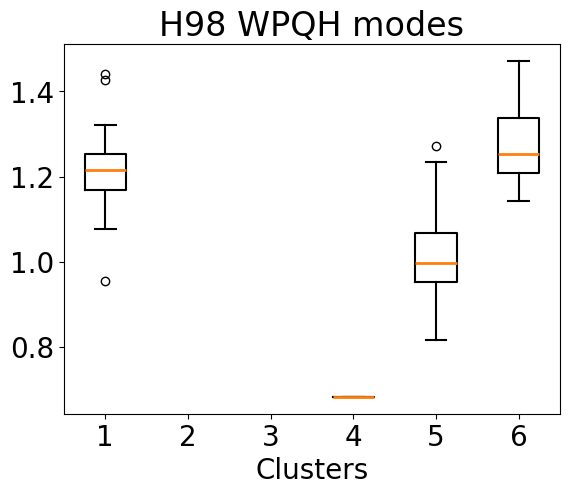

In [38]:
plt.figure()
plt.title('H98 WPQH modes')
plt.xlabel('Clusters')
plt.ylabel('')

plt.boxplot(WPQH_mode_h98_dict.values(), **boxplot_style)
plt.show()

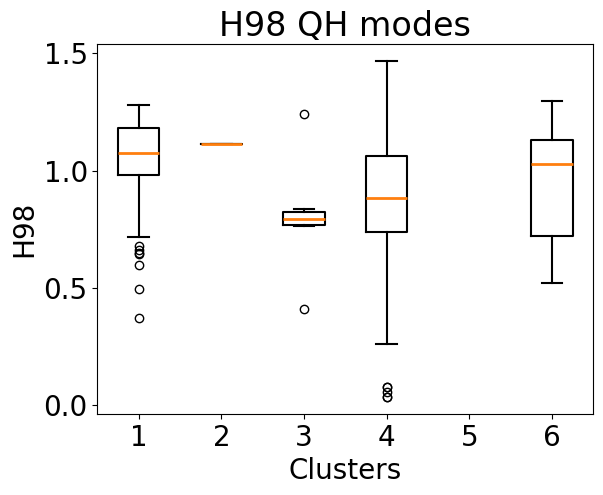

In [39]:
plt.figure()
plt.title('H98 QH modes')
plt.xlabel('Clusters')
plt.ylabel('H98')

plt.boxplot(QH_mode_h98_dict.values(), **boxplot_style)
plt.show()

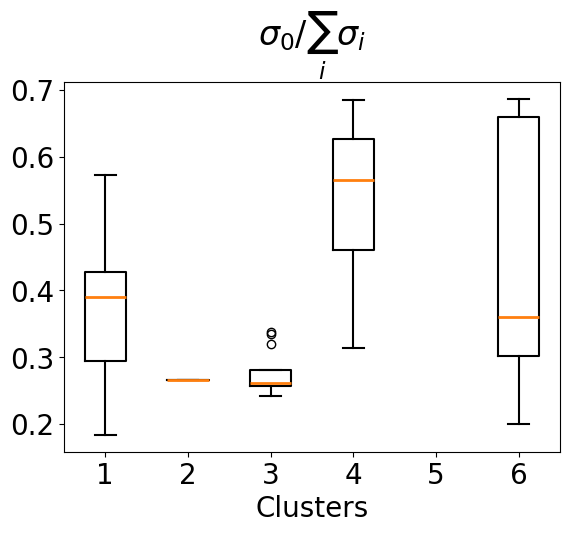

In [40]:
plt.figure()
plt.title(r'$\sigma_0/ \sum_i \sigma_i$')
plt.xlabel('Clusters')
plt.ylabel('')

plt.boxplot(QH_mode_S_dict.values(), **boxplot_style)
plt.show()

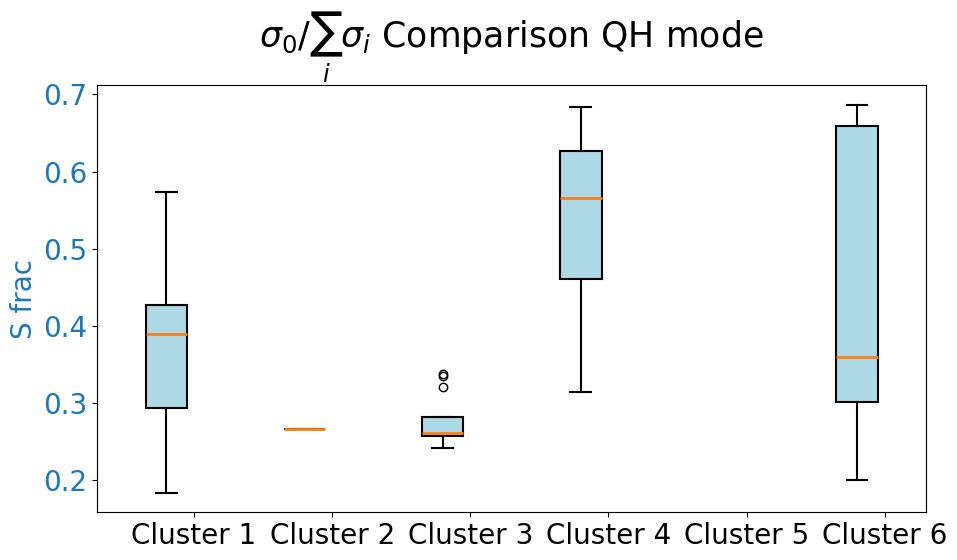

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare data (excluding cluster '2')
s_data = [QH_mode_S_dict[c] for c in QH_mode_S_dict]
labels = [f"Cluster {c}" for c in QH_mode_S_dict ]

fig, ax1 = plt.subplots(figsize=(10, 6))

# Define positions for the boxes to avoid overlap
# [0.8, 1.8, ...] for the first set, [1.2, 2.2, ...] for the second
positions_s = np.arange(1, len(s_data) + 1) - 0.2


# 2. Plot first axis (S frac)
bp1 = ax1.boxplot(s_data, positions=positions_s, widths=0.3, 
                  patch_artist=True, **boxplot_style)
ax1.set_xlabel('', fontsize=20)
ax1.set_ylabel('S frac', color='tab:blue', fontsize=20)
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 3. Create second axis (q95)


# 4. Cleanup and Labels
ax1.set_xticks(np.arange(1, len(labels) + 1))
ax1.set_xticklabels(labels)
plt.title(r'$\sigma_0/ \sum_i \sigma_i$ Comparison QH mode', fontsize=25)

# Optional: Color the boxes differently to match the axes
for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')

plt.tight_layout()

# plt.savefig('Paper_figures/combined_QH_boxplot.pdf', dpi=600)
plt.show()

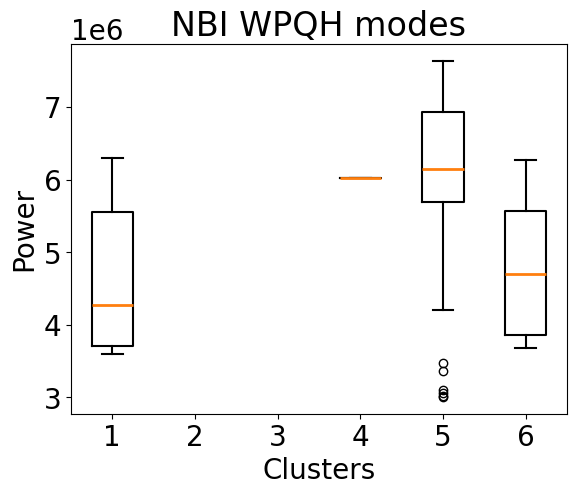

In [42]:
plt.figure()
plt.title('NBI WPQH modes')
plt.xlabel('Clusters')
plt.ylabel('Power')

plt.boxplot(WPQH_mode_NBI_dict.values(), **boxplot_style)
plt.show()

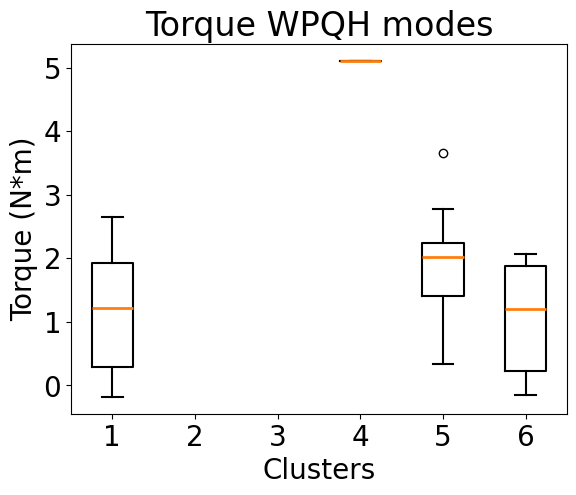

In [43]:
plt.figure()
plt.title('Torque WPQH modes')
plt.xlabel('Clusters')
plt.ylabel('Torque (N*m)')

plt.boxplot(WPQH_mode_torque_dict.values(), **boxplot_style)
plt.show()

In [44]:
print(NBI_dict.keys())

dict_keys(['00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009', '00010', '00011', '00012', '00013', '00014', '00015', '00016', '00017', '00018', '00019', '00020', '00021', '00022', '00023', '00024', '00025', '00026', '00027', '00028', '00029', '00030', '00031', '00032', '00033', '00034', '00035', '00036', '00037', '00038', '00039', '00040', '00041', '00042', '00043', '00044', '00045', '00046', '00047', '00048', '00049', '00050', '00051', '00052', '00053', '00054', '00055', '00056', '00057', '00058', '00059', '00060', '00061', '00062', '00063', '00064', '00065', '00066', '00067', '00068', '00069', '00070', '00071', '00072', '00073', '00074', '00075', '00076', '00077', '00078', '00079', '00080', '00081', '00082', '00083', '00084', '00085', '00086', '00087', '00088', '00089', '00090', '00091', '00092', '00093', '00094', '00095', '00096', '00097', '00098', '00099', '00100', '00101', '00102', '00103', '00104', '00105', '00106', '00107', '00108', '00109', '00110',

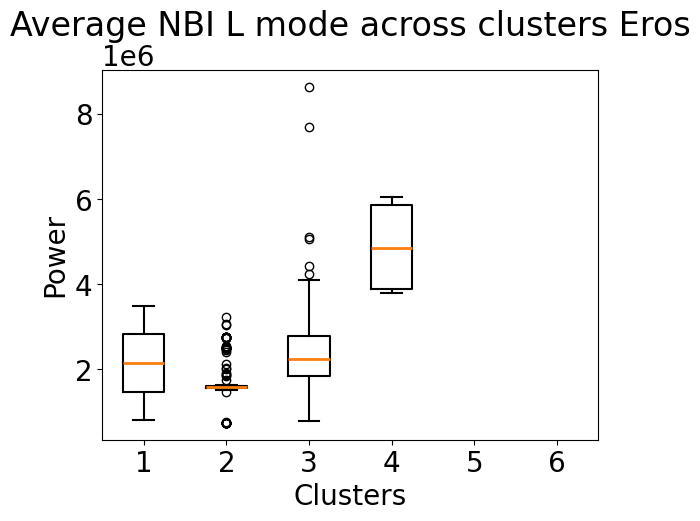

In [45]:
plt.figure()
plt.title('Average NBI L mode across clusters Eros')
plt.xlabel('Clusters')
plt.ylabel('Power')

plt.boxplot(L_mode_NBI_dict.values(), **boxplot_style)
plt.show()

In [46]:
def id_removal(data_dict):
    ids_to_pop = []
    for id in data_dict.keys():
        try: 
            data_dict[id]['signals']
        except:
            ids_to_pop.append(id)

    for id in ids_to_pop:
        data_dict.pop(id)
    return data_dict

In [47]:
torque_dict = id_removal(torque_dict)
NBI_dict = id_removal(NBI_dict)
ECH_dict = id_removal(ECH_dict)

In [48]:
torque_cluster_dict = cluster_func.cluster_comparison(torque_dict, cluster_dict_new, signals = True)

In [49]:
torque_dict['00001']['signals']

np.float64(0.9199372939765453)

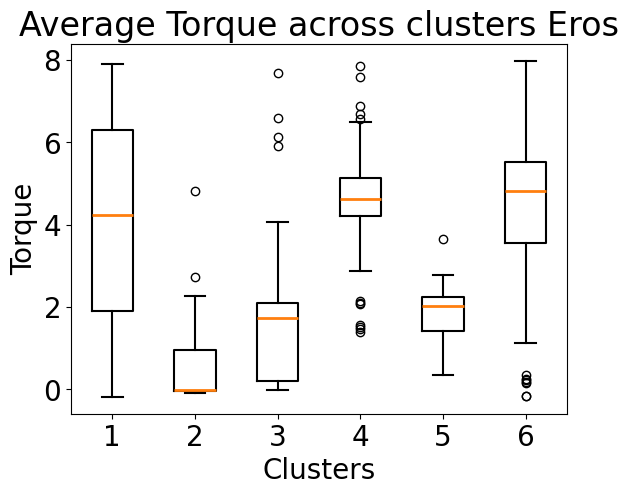

In [50]:
plt.figure()
plt.title('Average Torque across clusters Eros')
plt.xlabel('Clusters')
plt.ylabel('Torque')

plt.boxplot(torque_cluster_dict.values(), **boxplot_style)
plt.show()

# We would like to do within cluster comparison of the 7th and 8th cluster

In [51]:
def in_cluster_comparison(data_dict, cluster_dict, bes_dict, cluster_num, dt = 1):
    #can use dt to correct any scaling errors if need be
    data_cluster_dict = {'L': [], 'QH': [], 'WPQH': []}
    num_missing = 0
    total_keys = len(list(data_dict.keys()))
    for id in cluster_dict[str(cluster_num)]:
        try:
            data_dict[id]['signals']
        except:
            num_missing+=1
            continue
        if bes_dict[id]['label'] == 0:
            data_cluster_dict['L'].append(data_dict[id]['signals']*dt)

        if bes_dict[id]['label'] == 2:
            data_cluster_dict['QH'].append(data_dict[id]['signals']*dt)

        if bes_dict[id]['label'] == 3:
            data_cluster_dict['WPQH'].append(data_dict[id]['signals']*dt)
    print(f'missing {num_missing} of {total_keys} keys')
    return data_cluster_dict

In [52]:
torque_cluster_1_dict = in_cluster_comparison(torque_dict, cluster_dict_new, bes_dict, 1)

missing 0 of 3876 keys


In [53]:
torque_cluster_3_dict = in_cluster_comparison(torque_dict, cluster_dict_new, bes_dict, 3)

missing 0 of 3876 keys


In [54]:
NBI_cluster_dict = cluster_func.cluster_comparison(NBI_dict, cluster_dict_new, signals = True)

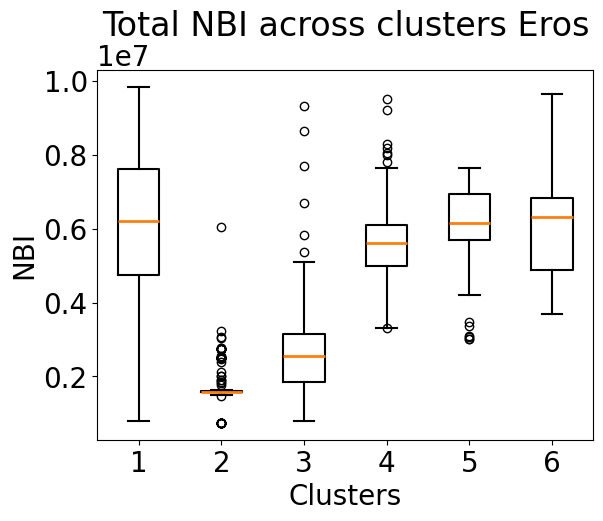

In [55]:
plt.figure()
plt.title('Total NBI across clusters Eros')
plt.xlabel('Clusters')
plt.ylabel('NBI')
plt.boxplot(NBI_cluster_dict.values(), **boxplot_style)
plt.show()

In [56]:
NBI_cluster_1_dict = in_cluster_comparison(NBI_dict, cluster_dict_new, bes_dict, 1)
NBI_cluster_2_dict = in_cluster_comparison(NBI_dict, cluster_dict_new, bes_dict, 2)



missing 0 of 3876 keys
missing 0 of 3876 keys


In [57]:
def numfmt_mega(x, pos):
    s = f'{x/10**6}'
    return s

yfmt_mega = tkr.FuncFormatter(numfmt_mega)

def numfmt_kila(x, pos):
    s = f'{x/10**3}'
    return s

yfmt_kila = tkr.FuncFormatter(numfmt_kila)


In [58]:
# S_cluster_2_WPQH = {'WPQH': []}
# S_cluster_3_WPQH = {'WPQH': []}
# S_cluster_4_WPQH = {'WPQH': []}
# for id in cluster_dict_new['3']:
#     label = bes_dict[id]['label']
#     if label == 3: #3 is the numeric label for WPQH
#         S = np.linalg.svd(bes_dict[id]['signals'], full_matrices=False)[1]
#         S_frac = S[0]/np.sum(S)
#         S_cluster_3_WPQH['WPQH'].append(S_frac)
#     else:
#         continue


# for cluster in cluster_dict_new.keys():

#     for id in cluster_dict_new[cluster]:
#         label = bes_dict[id]['label']
#         if label == 3: #3 is the numeric label for WPQH
#             S = Eros_dict[id]['S']
#             S_frac = S[0]/np.sum(S)
#             if cluster == '2':
#                 S_cluster_2_WPQH['WPQH'].append(S_frac)
#             if cluster == '3':
#                 S_cluster_3_WPQH['WPQH'].append(S_frac)
#             if cluster == '4':
#                 S_cluster_4_WPQH['WPQH'].append(S_frac)
#         else:
#             continue


# The H98 dict contains np.inf's which xgboost does not like. Need to change these to np.nan. Also add abs(bt) and abs(ip) and pedestal widths

In [59]:
pedestal_height_dict = np.load('elm_free_bes_data/pedestal_heights.npy', allow_pickle = True).item()

pe_wid_dict = {id: pedestal_dict[id]['pe']['foot'] - pedestal_dict[id]['pe']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}
ne_wid_dict = {id: pedestal_dict[id]['ne']['foot'] - pedestal_dict[id]['ne']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}
te_wid_dict = {id: pedestal_dict[id]['te']['foot'] - pedestal_dict[id]['te']['top'] for id in pedestal_dict.keys() if len(pedestal_dict[id]) != 0}


pe_height_dict = {id: pedestal_height_dict[id]['pe']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['pe'] != 0}
ne_height_dict = {id: pedestal_height_dict[id]['ne']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['ne'] != 0}
te_height_dict = {id: pedestal_height_dict[id]['te']  for id in pedestal_height_dict.keys() if pedestal_height_dict[id]['te'] != 0}

pe_gradient_dict = {id: pedestal_height_dict[id]['pe']/pe_wid_dict[id] for id in pedestal_height_dict.keys() if id in pe_wid_dict.keys() and pe_wid_dict[id] != 0.0}
te_gradient_dict = {id: pedestal_height_dict[id]['te']/te_wid_dict[id] for id in pedestal_height_dict.keys() if id in pe_wid_dict.keys() and te_wid_dict[id] != 0.0}
ne_gradient_dict = {id: pedestal_height_dict[id]['ne']/ne_wid_dict[id] for id in pedestal_height_dict.keys() if id in pe_wid_dict.keys() and ne_wid_dict[id] != 0.0}


for id in event_ids:
    try:
        pe_wid_dict[id]
    except:
        pe_wid_dict[id] = 'NA'
    try:
        ne_wid_dict[id]
    except:
        ne_wid_dict[id] = 'NA'
    try:
        te_wid_dict[id]
    except:
        te_wid_dict[id] = 'NA'


#favorable vs. unfavorable drif can be determined as follows: if Bt * Ip * drsep > 0: favorable, else unfavorable
drift_direction_dict = {id: np.sign(bt_dict[id]*ip_dict[id]*drsep_dict[id]) for id in event_ids if drsep_dict[id] != 'NA'}

In [60]:
for id in h98_dict.keys():
    if h98_dict[id] == np.inf:
        h98_dict[id] = np.nan

In [61]:
dict_list = [q95_dict, tritop_dict, tribot_dict, kappa_dict, bt_mag_dict, ip_mag_dict, drsep_dict, betan_dict, NBI_dict, torque_dict, 
             h98_dict, S_sum_S_dict, pe_height_dict, te_height_dict, ne_height_dict,  pe_wid_dict, te_wid_dict, ne_wid_dict,
             pe_gradient_dict, te_gradient_dict, ne_gradient_dict, drift_direction_dict]
names = ['$q_{95}$', r'$\delta_t$', r'$\delta_b$', r'$\kappa$', r'$|\text{B}_\text{t}|$', 
         r'$|\text{I}_\text{p}|$', r'dr_$\text{sep}$', r'$\beta_n$', 'NBI', 'torque', r'$\text{H}_{98}$', 
         r'$\sigma_0/ \sum_i \sigma_i$', r'P$_e$', r'T$_e$', r'n$_e$', 
         r'P$_e \text{width}$', r'T$_e \text{width}$', r'n$_e \text{width}$',
         r'$\nabla$ P$_e$', r'$\nabla$ T$_e$', r'$\nabla$ n$_e$', 'drift direction']

#need to reshape the cluster dict so each id has a label of which cluster it's in associated with it
cluster_dict_reshape = {}
clusters = sorted(list(cluster_dict_new.keys()))
cluster_conversion = {cluster: idx for idx,cluster in enumerate(clusters)}
for cluster in clusters:
    ids = cluster_dict_new[cluster]
    temp = {id: cluster_conversion[cluster] for id in ids}
    cluster_dict_reshape.update(temp)
cluster_df = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape)})

[np.str_('03079'), np.str_('03436'), np.str_('00033'), np.str_('00100'), np.str_('00101'), np.str_('00150'), np.str_('00151'), np.str_('00152'), np.str_('00154'), np.str_('00155'), np.str_('00238'), np.str_('00239'), np.str_('00240'), np.str_('00241'), np.str_('00242'), np.str_('00253'), np.str_('00342'), np.str_('00344'), np.str_('00345'), np.str_('00540'), np.str_('00544'), np.str_('00545'), np.str_('00559'), np.str_('00561'), np.str_('00562'), np.str_('00563'), np.str_('00564'), np.str_('00565'), np.str_('00566'), np.str_('00568'), np.str_('00569'), np.str_('00570'), np.str_('00571'), np.str_('00572'), np.str_('00573'), np.str_('00574'), np.str_('00575'), np.str_('00596'), np.str_('00597'), np.str_('00598'), np.str_('00599'), np.str_('00600'), np.str_('00601'), np.str_('00606'), np.str_('00607'), np.str_('00608'), np.str_('00609'), np.str_('00610'), np.str_('00611'), np.str_('00612'), np.str_('00613'), np.str_('00629'), np.str_('00631'), np.str_('00632'), np.str_('00642'), np.str_('

/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 1/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.871 total time=   0.3s
[CV 2/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.817 total time=   0.1s
[CV 3/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.777 total time=   0.1s
[CV 4/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.817 total time=   0.1s
[CV 5/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.859 total time=   0.1s
[CV 6/10] 

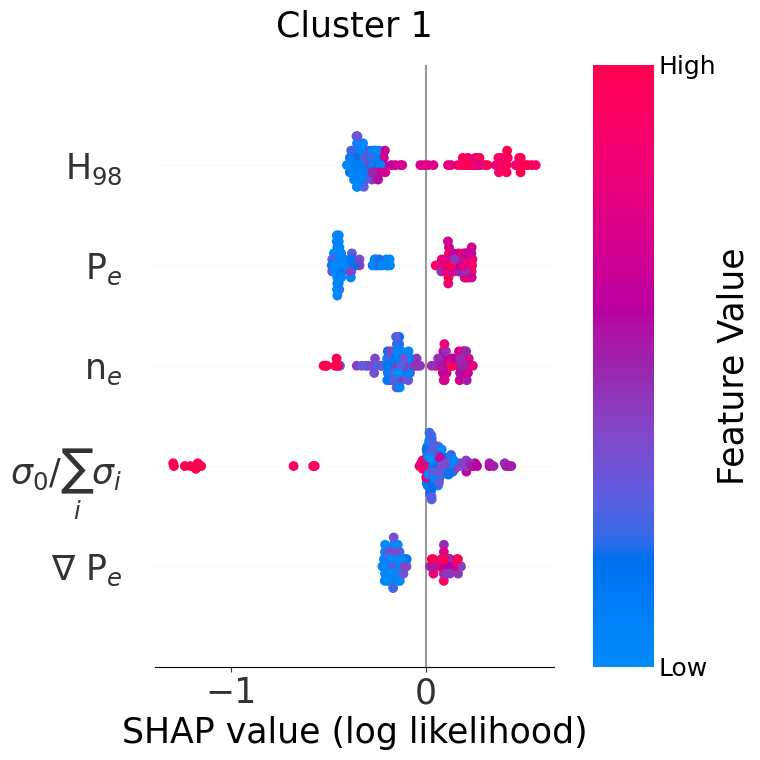

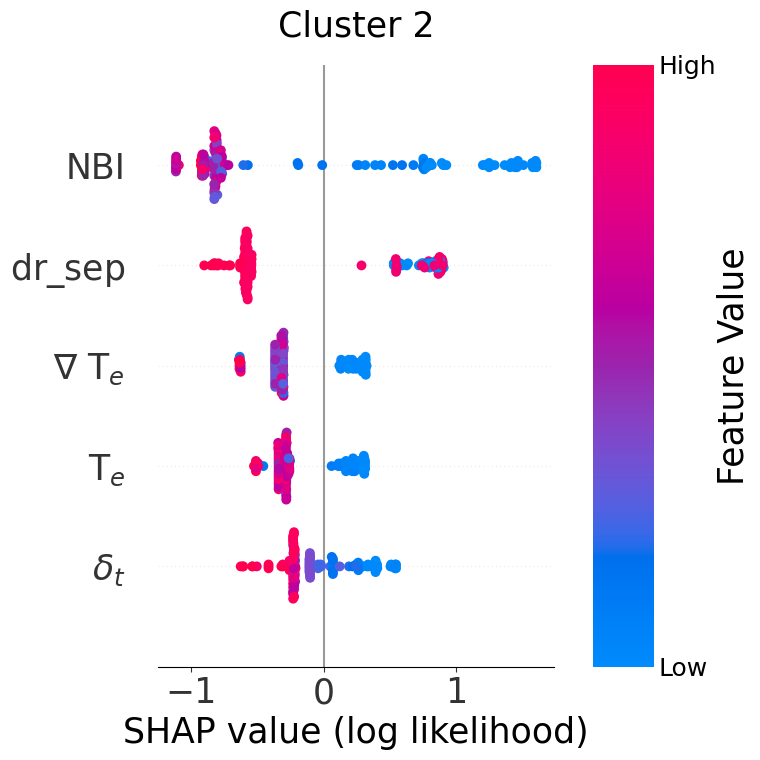

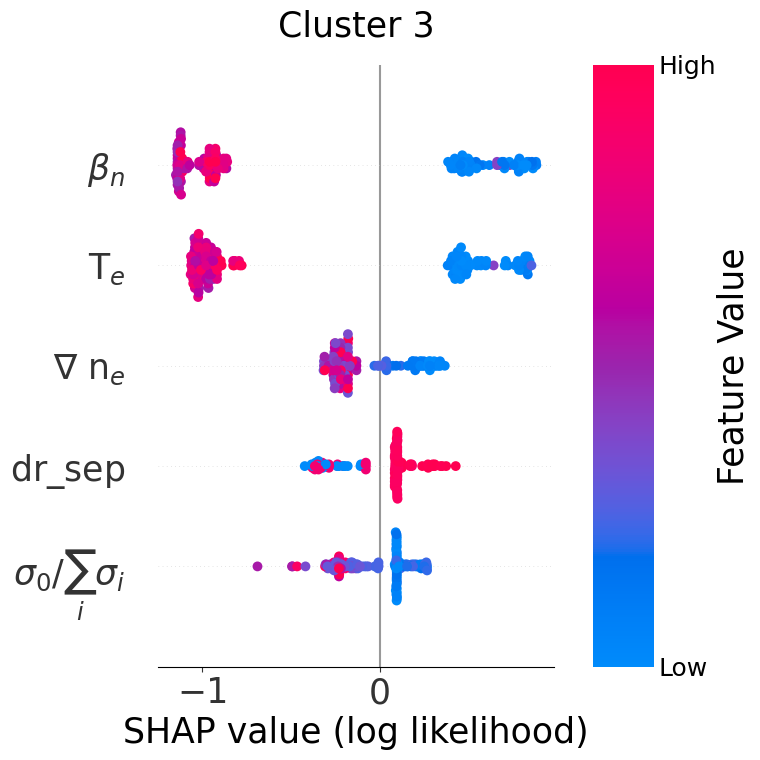

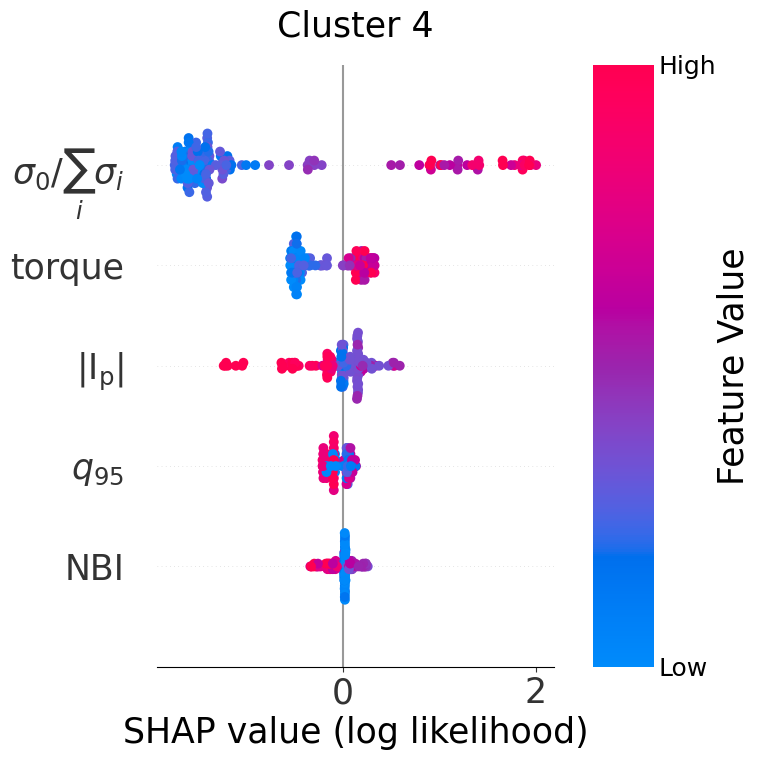

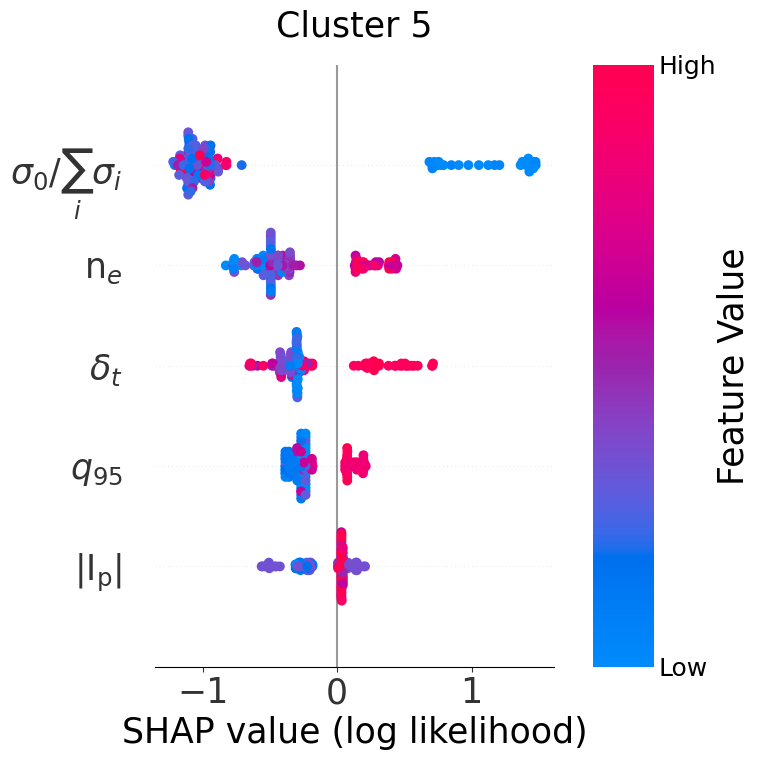

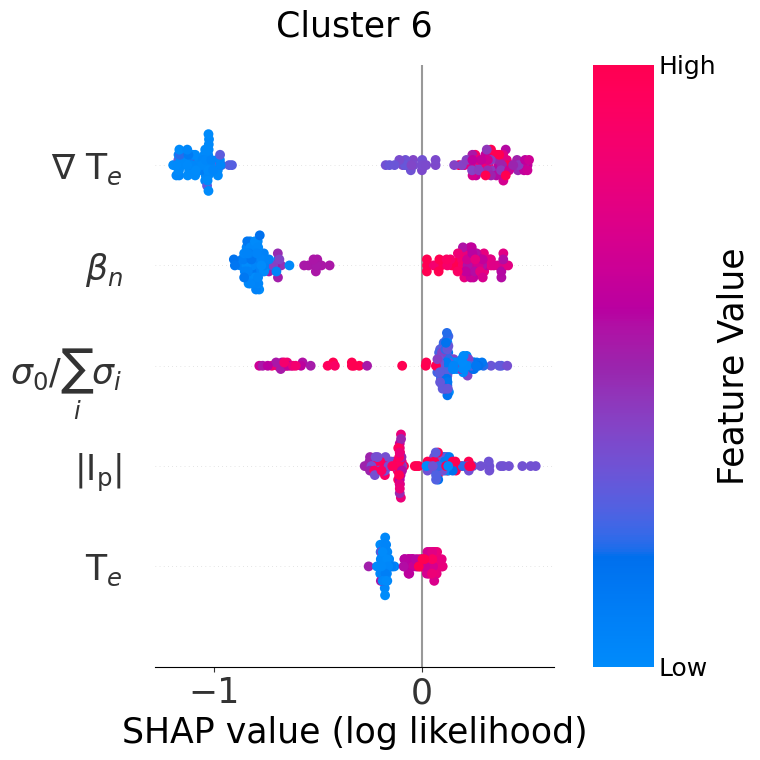

In [62]:
ids = list(cluster_dict_reshape.keys())

print(ids)

feature_dataframe = cluster_func.to_dataframe(dict_list, names, ids)


cluster_func.SHAP_analysis(feature_dataframe, cluster_df, num_clusters_new)

# QH mode SHAP analysis

In [63]:

#need to reshape the cluster dict so each id has a label of which cluster it's in associated with it
cluster_dict_reshape_QH = {}
clusters = sorted(list(cluster_dict_new.keys()))
cluster_conversion = {}
for idx,cluster in enumerate(clusters):
    if cluster == '4':
        cluster_conversion[cluster] = idx
    elif cluster == '1' or '6':
        cluster_conversion['2'] = idx

ids_QH = []
for cluster in clusters:
    ids = cluster_dict_new[cluster]
    temp = {}
    for id in ids:
        primary_cluster_bool = cluster == '4' 
        secondary_cluster_bool = cluster == '1' or cluster == '6'
        if bes_dict[id]['label'] == 2 and primary_cluster_bool:
            temp[id] = cluster_conversion[cluster]
            ids_QH.append(id)
        elif bes_dict[id]['label'] == 2 and secondary_cluster_bool:
            temp[id] = cluster_conversion['2']
            ids_QH.append(id)
    cluster_dict_reshape_QH.update(temp)
cluster_df_QH = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape_QH)})

In [64]:
print(len(ids_QH))

280


Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.848 total time=   0.0s
[CV 2/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.951 total time=   0.0s
[CV 3/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 4/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.873 total time=   0.0s
[CV 5/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample

/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


[CV 7/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 8/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.908 total time=   0.0s
[CV 9/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.782 total time=   0.0s
[CV 10/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.949 total time=   0.0s
[CV 1/10] END colsample_bytree=0.5779972601681014, learning_rate=0.026844247528777843, max_depth=6, min_child_weight=4, n_estimators=89, subsample=0.8540362888980227;, score=0.900 total time=   0.0s
[CV 2/10

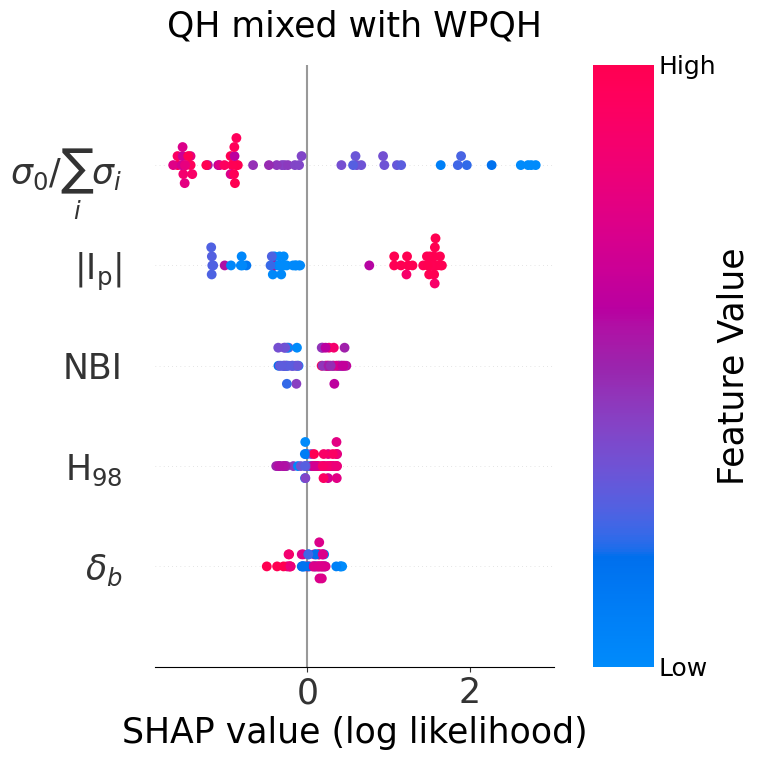

In [65]:
QH_feature_dataframe = cluster_func.to_dataframe(dict_list, names, ids_QH)



QH_fig, QH_axs = cluster_func.SHAP_analysis(QH_feature_dataframe, cluster_df_QH, 2, return_fig= True, title = 'QH mixed with WPQH')

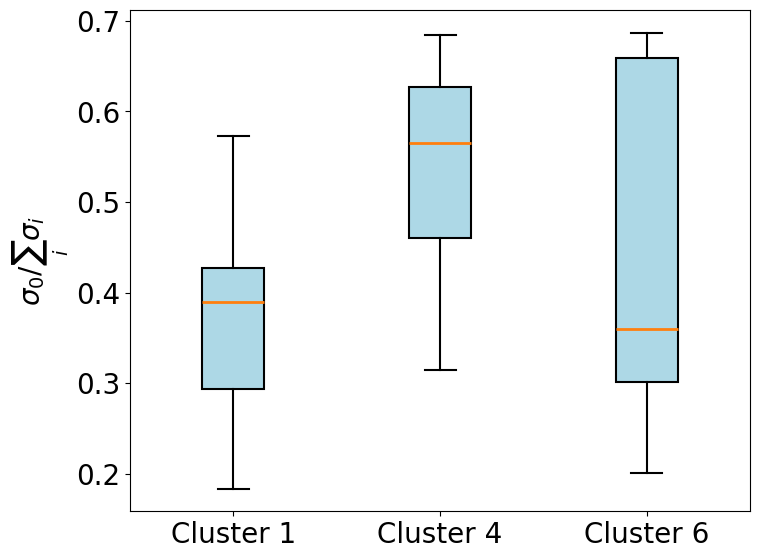

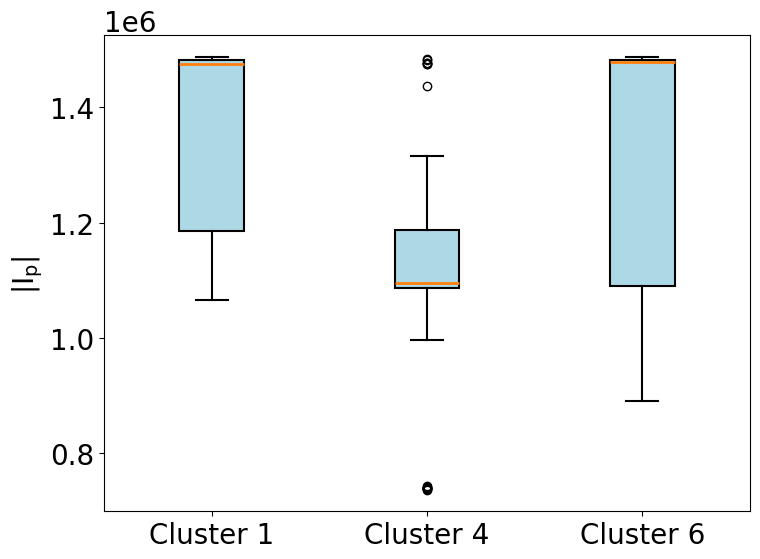

In [66]:
pastel_boxplot(QH_mode_S_dict, ['1', '4', '6'], y_axis = r'$\sigma_0/ \sum_i \sigma_i$')
pastel_boxplot(QH_mode_mag_ip_dict, ['1', '4', '6'], y_axis = r'$|\text{I}_{\text{p}}|$')


In [67]:
for k,i in enumerate(QH_fig):
    i.savefig(f'Paper_figures/SHAP_QH_cluster_{k+1}_magnetics_edge.pdf', dpi = 600)

# WPQH mode SHAP analysis

In [68]:

#need to reshape the cluster dict so each id has a label of which cluster it's in associated with it
cluster_dict_reshape_WPQH = {}
clusters = sorted(list(cluster_dict_new.keys()))
cluster_conversion = {cluster: idx for idx,cluster in enumerate(clusters)}
ids_WPQH = []
for cluster in clusters:
    ids = cluster_dict_new[cluster]
    temp = {}
    for id in ids:
        cluster_bool = cluster == '1' or cluster == '5' 
        if bes_dict[id]['label'] == 3 and cluster_bool:
            temp[id] = cluster_conversion[cluster]
            ids_WPQH.append(id)
    cluster_dict_reshape_WPQH.update(temp)
cluster_df_WPQH = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape_WPQH)})

In [69]:
cluster_dict_reshape_WPQH = {}
clusters = sorted(list(cluster_dict_new.keys()))
cluster_conversion = {}
for idx,cluster in enumerate(clusters):
    if cluster == '5':
        cluster_conversion[cluster] = idx
    elif cluster == '1' or '6':
        cluster_conversion['2'] = idx

ids_WPQH = []
for cluster in clusters:
    ids = cluster_dict_new[cluster]
    temp = {}
    for id in ids:
        primary_cluster_bool = cluster == '5' 
        secondary_cluster_bool = cluster == '1' or cluster == '6'
        if bes_dict[id]['label'] == 3 and primary_cluster_bool:
            temp[id] = cluster_conversion[cluster]
            ids_WPQH.append(id)
        elif bes_dict[id]['label'] == 3 and secondary_cluster_bool:
            temp[id] = cluster_conversion['2']
            ids_WPQH.append(id)
    cluster_dict_reshape_WPQH.update(temp)
cluster_df_WPQH = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape_WPQH)})

/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.923 total time=   0.0s
[CV 2/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 3/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 4/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.924 total time=   0.0s
[CV 5/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample

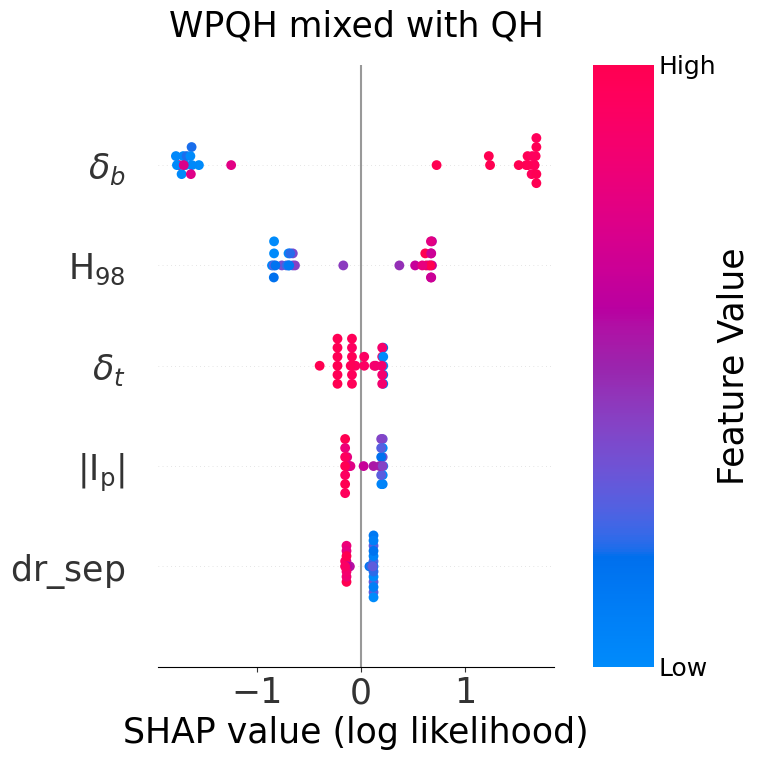

In [70]:

feature_dataframe = cluster_func.to_dataframe(dict_list, names, ids_WPQH)



WPQH_fig, WPQH_axs = cluster_func.SHAP_analysis(feature_dataframe, cluster_df_WPQH, num_cat = 2, return_fig=True, title = 'WPQH mixed with QH')

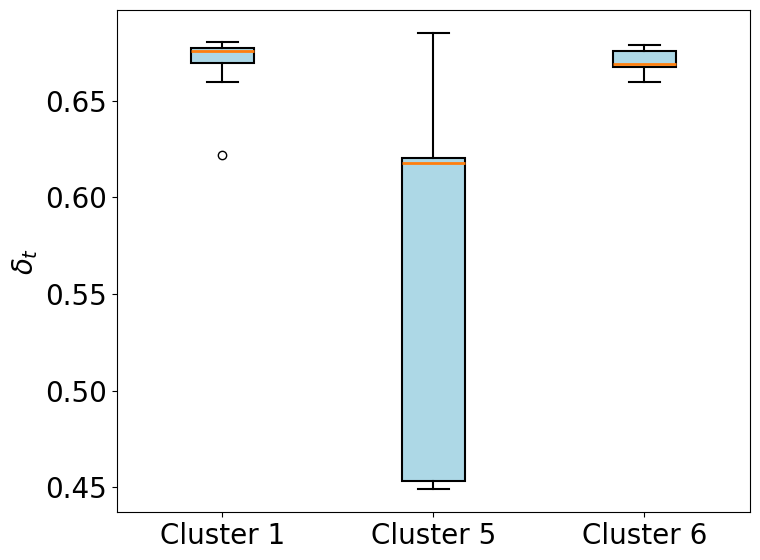

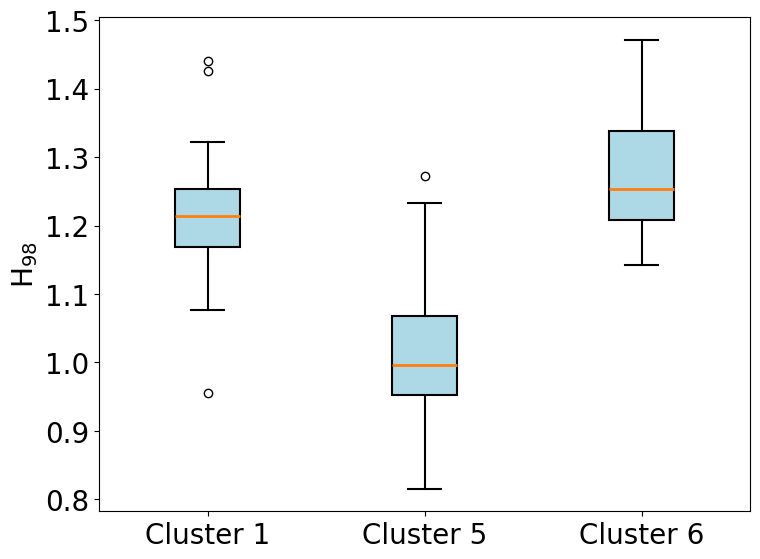

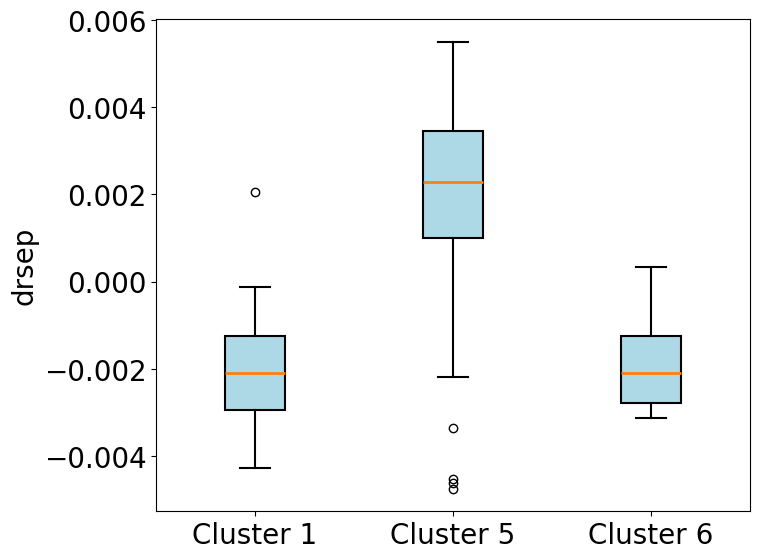

In [71]:
pastel_boxplot(WPQH_mode_tribot_dict, ['1','5','6'], y_axis = r'$\delta_t$')
pastel_boxplot(WPQH_mode_h98_dict, ['1','5','6'], y_axis = r'$\text{H}_{98}$')
pastel_boxplot(WPQH_mode_drsep_dict, ['1', '5', '6'], y_axis = 'drsep')

In [72]:
for k,i in enumerate(WPQH_fig):
    i.savefig(f'Paper_figures/SHAP_WPQH_cluster_{k+1}_magnetics_edge.pdf', dpi = 600)

# L mode SHAP analysis

In [73]:

#need to reshape the cluster dict so each id has a label of which cluster it's in associated with it
cluster_dict_reshape_L = {}
clusters = sorted(list(cluster_dict_new.keys()))
cluster_conversion = {cluster: idx for idx,cluster in enumerate(clusters)}
ids_L = []
for cluster in clusters:
    ids = cluster_dict_new[cluster]
    temp = {}
    for id in ids:
        cluster_bool = cluster == '2' or cluster == '3' 
        if bes_dict[id]['label'] == 0 and cluster_bool:
            temp[id] = cluster_conversion[cluster]
            ids_L.append(id)
    cluster_dict_reshape_L.update(temp)
cluster_df_L = pd.DataFrame({'Cluster': pd.Series(cluster_dict_reshape_L)})

/mnt/homes/zld2104/miniconda3/envs/clustering/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV 1/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.938 total time=   0.0s
[CV 2/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=1.000 total time=   0.0s
[CV 3/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.966 total time=   0.0s
[CV 4/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample=0.5780093202212182;, score=0.938 total time=   0.0s
[CV 5/10] END colsample_bytree=0.6872700594236812, learning_rate=0.28570714885887566, max_depth=4, min_child_weight=5, n_estimators=70, subsample

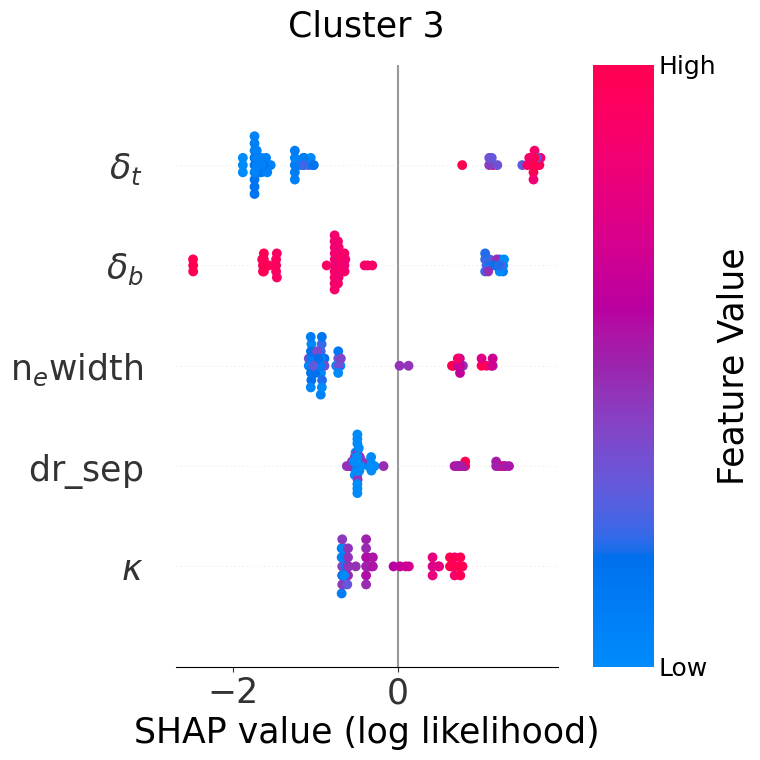

In [74]:
L_dict_list = [q95_dict, tritop_dict, tribot_dict, kappa_dict, bt_mag_dict, ip_mag_dict, drsep_dict, betan_dict, NBI_dict, torque_dict, 
              S_sum_S_dict, pe_height_dict, te_height_dict, ne_height_dict,  pe_wid_dict, te_wid_dict, ne_wid_dict,
             pe_gradient_dict, te_gradient_dict, ne_gradient_dict, drift_direction_dict]
L_names = ['$q_{95}$', r'$\delta_t$', r'$\delta_b$', r'$\kappa$', r'$|\text{B}_\text{t}|$', 
         r'$|\text{I}_\text{p}|$', r'dr_$\text{sep}$', r'$\beta_n$', 'NBI', 'torque', 
         r'$\sigma_0/ \sum_i \sigma_i$', r'P$_e$', r'T$_e$', r'n$_e$', 
         r'P$_e \text{width}$', r'T$_e \text{width}$', r'n$_e \text{width}$',
         r'$\nabla$ P$_e$', r'$\nabla$ T$_e$', r'$\nabla$ n$_e$', 'drift direction']
L_feature_dataframe = cluster_func.to_dataframe(L_dict_list, L_names, ids_L)



L_fig, L_axs = cluster_func.SHAP_analysis(L_feature_dataframe, cluster_df_L, 2, return_fig=True,)

In [75]:
for k,i in enumerate(L_fig):
    i.savefig(f'Paper_figures/SHAP_L_cluster_{k+1}_magnetics_edge.pdf', dpi = 600)

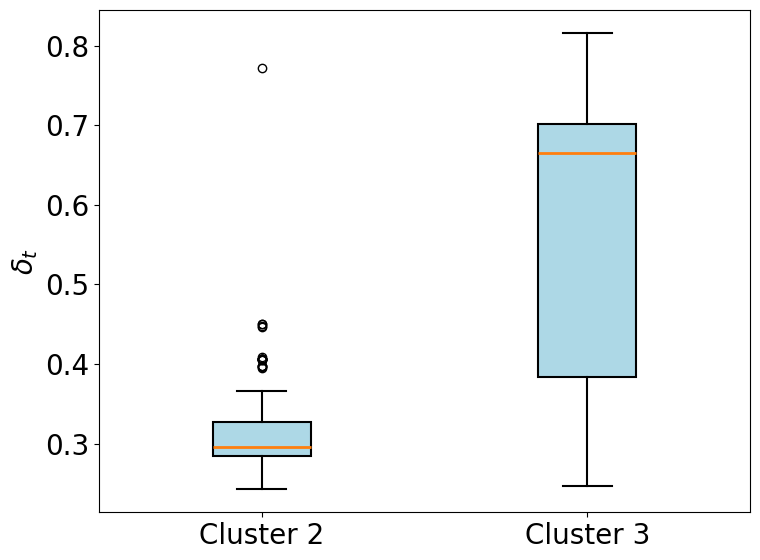

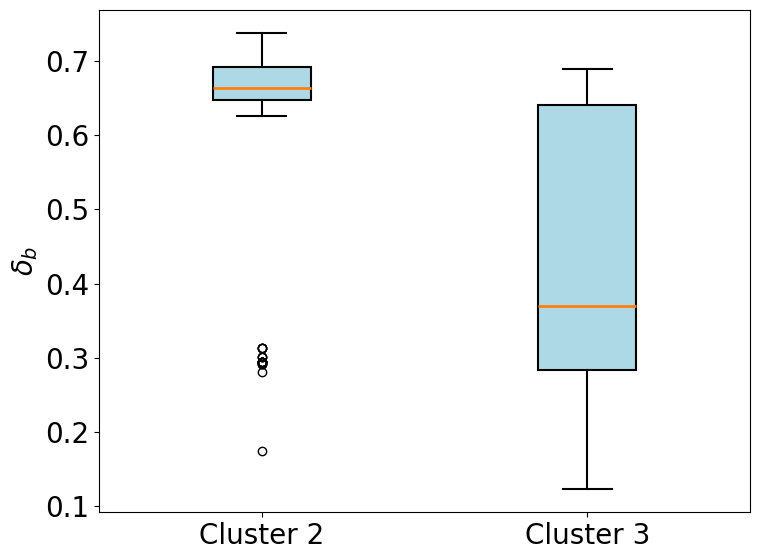

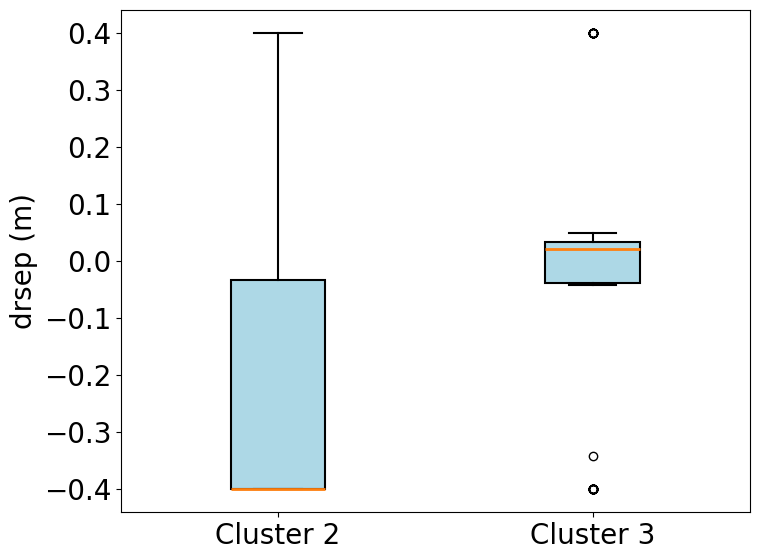

In [76]:

L_mode_tritop_fig = pastel_boxplot(L_mode_tritop_dict, ['2','3'], y_axis = r'$\delta_{t}$',return_fig=True)
L_mode_tribot_fig = pastel_boxplot(L_mode_tribot_dict, ['2','3'], y_axis = r'$\delta_{b}$', return_fig=True)
L_mode_drsep_fig = pastel_boxplot(L_mode_drsep_dict, ['2','3'], y_axis = r'drsep (m)', return_fig=True)


In [77]:
L_mode_tribot_fig.savefig('Paper_figures/L_mode_tribot_boxplot_magnetics_edge.pdf', dpi = 600)
L_mode_tritop_fig.savefig('Paper_figures/L_mode_tritop_boxplot_magnetics_edge.pdf', dpi = 600)
L_mode_drsep_fig.savefig('Paper_figures/L_mode_drsep_boxplot_magnetics_edge.pdf', dpi = 600)

In [78]:
L_mode_drift_direction_dict = {'3': [], '4':[]}

for cluster in cluster_dict_new:
    for id in cluster_dict_new[cluster]:
        label = bes_dict[id]['label']
        if label == 0:
            if cluster == '3':
                L_mode_drift_direction_dict['3'].append(drift_direction_dict[id])
            if cluster == '4':
                L_mode_drift_direction_dict['4'].append(drift_direction_dict[id])

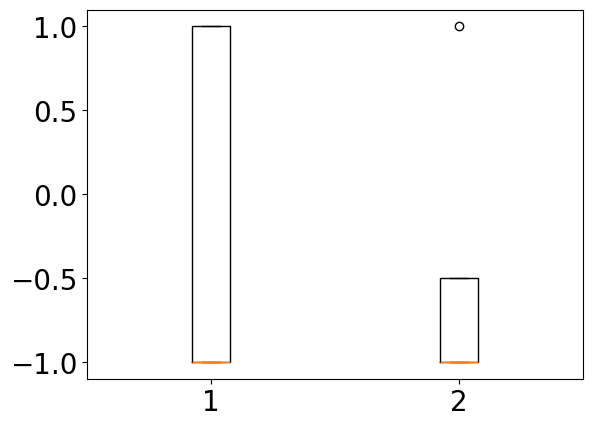

In [79]:
plt.boxplot(L_mode_drift_direction_dict.values())
plt.show()